# Debugging xy shift in WN regen

In [5]:
import retinanalysis as ra
import numpy as np
import matplotlib.pyplot as plt
import mat73
from scipy.io import loadmat
import os
print(ra.settings.ANALYSIS_DIR)
import sys
# sys.path.append('/home/vyomr/Desktop/gitrepos/retinanalysis/src/retinanalysis/utils/')
sys.path.append('/Users/riekelabbackup/Desktop/Vyom/RetinAnalysis/src/retinanalysis/utils/')
import regen
import importlib
importlib.reload(regen)
import cv2

/Volumes/Vyom MEA/analysis


## no jitter case

In [3]:
exp_name = '20251121_noise_regen'
df_exp = ra.get_exp_summary(exp_name)
df_exp

,exp_name,prep_label,cell_id,cell_label,cell_type,NDF,protocol_name,duration_minutes,minutes_since_start,start_time,end_time,cell_properties,group_label,experiment_id,prep_id,group_id,block_id,protocol_id
0,20251121_noise_regen,Preparation,207,Cell,RGC,NaN,manookinlab.protocols.SpatialNoise,0.02,0.02,2025-11-21 10:33:59,2025-11-21 10:34:00,{'type': 'RGC'},no jitter,173,201,2709,4095,19
1,20251121_noise_regen,Preparation,207,Cell,RGC,NaN,manookinlab.protocols.SpatialNoise,0.02,0.43,2025-11-21 10:34:24,2025-11-21 10:34:25,{'type': 'RGC'},jitter,173,201,2710,4096,19


In [10]:
bid = df_exp.at[0, 'block_id']
sb0 = ra.StimBlock(exp_name, bid)

bid = df_exp.at[1, 'block_id']
sb1 = ra.StimBlock(exp_name, bid)

Initializing StimBlock for 20251121_noise_regen block 4095
Initializing StimBlock for 20251121_noise_regen block 4096


In [14]:
sb0.df_epochs['group_label'].values[0], sb1.df_epochs['group_label'].values[0]

('no jitter', 'jitter')

In [59]:
importlib.reload(regen)
str_vid0 = '/Volumes/Vyom MEA/data/samarjit_datajoint/data_dirs/no_jitter_2025-11-21 10-33-57.mp4'
str_vid1 = '/Volumes/Vyom MEA/data/samarjit_datajoint/data_dirs/jitter_2025-11-21 10-34-21.mp4'
# (400, 600) canvas, but cropping right frame monitor strip
canvas_size = (400, 400)
eb0_rec = regen.load_mp4(str_vid0, b_crop_screencap=True, display_dims=canvas_size)
eb1_rec = regen.load_mp4(str_vid1, b_crop_screencap=True, display_dims=canvas_size)

Loaded 313 frames from /Volumes/Vyom MEA/data/samarjit_datajoint/data_dirs/no_jitter_2025-11-21 10-33-57.mp4
Frame shape: (313, 1080, 1920, 3)
Cropped frame shape: (313, 400, 400, 3)
Loaded 180 frames from /Volumes/Vyom MEA/data/samarjit_datajoint/data_dirs/jitter_2025-11-21 10-34-21.mp4
Frame shape: (180, 1080, 1920, 3)
Cropped frame shape: (180, 400, 400, 3)


Text(0.5, 1.0, 'First frame at index 112')

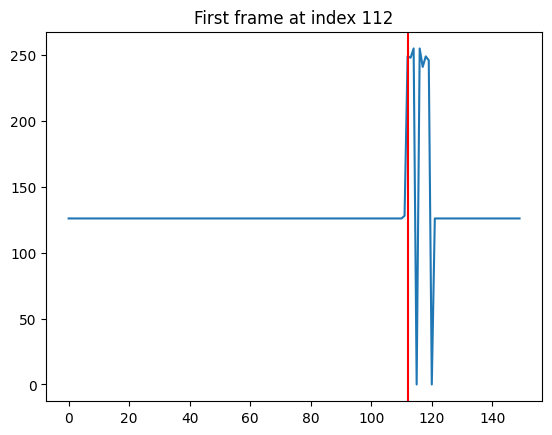

In [65]:
plt.plot(eb0_rec[:150,0,0,0])
# Detect first frame change
diffs = np.abs(np.diff(eb0_rec[:,0,0,0]))
frame_changes = np.where(diffs > 20)[0] + 1
frame_onset = frame_changes[0]
plt.axvline(frame_onset, color='r')
plt.title(f'First frame at index {frame_onset}')

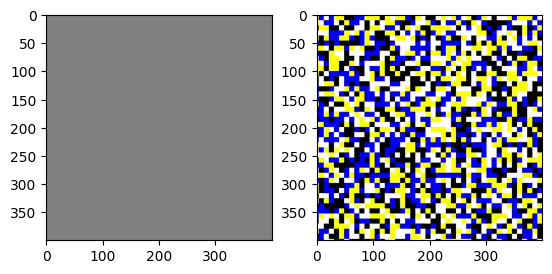

In [67]:
v_frames = eb0_rec[frame_onset:]
plt.subplot(1,2,1)
plt.imshow(eb0_rec[frame_onset-1])
plt.subplot(1,2,2)
plt.imshow(eb0_rec[frame_onset])

In [101]:
def plot_frame_comparison(v_frames, r_frames):
    # if v_frames (0, 255), scale to (0, 1)
    if v_frames.max() > 1.0:
        v_frames = v_frames / 255.0
    # if r_frames (-1, 1), scale to (0, 1)
    if r_frames.min() < 0.0:
        r_frames = (r_frames + 1) / 2.0
    
    # if r_frames larger, crop to match v_frames
    if r_frames.shape[1:3] != v_frames.shape[1:3]:
        min_y = min(r_frames.shape[1], v_frames.shape[1])
        min_x = min(r_frames.shape[2], v_frames.shape[2])
        r_frames = r_frames[:, :min_y, :min_x, :]
        v_frames = v_frames[:, :min_y, :min_x, :]

    f, axs = plt.subplots(ncols=3, figsize=(15,10))
    ls_f = [v_frames, r_frames]
    ls_titles = ['Stage screencap', 'Python regen']
    i_frame = 0 # 3 has 0 offset
    ax = axs[0]
    f = ls_f[0][i_frame]
    f = f[...,0]
    # f = cv2.resize(f, (203, 127), interpolation=cv2.INTER_NEAREST)
    im=ax.imshow(f)
    ax.set_title(ls_titles[0])
    ax.axis('off')

    ax = axs[1]
    f = ls_f[1][i_frame]
    f = f[...,0]
    # f = cv2.resize(f, (203, 127), interpolation=cv2.INTER_NEAREST)
    im=ax.imshow(f)
    ax.set_title(ls_titles[1])
    ax.axis('off')

    ax = axs[2]
    f = ls_f[0][i_frame] - ls_f[1][i_frame]
    f = f[...,0]
    # Scale difference to 0, 1
    f = (f - f.min()) / (f.max() - f.min())
    # f = cv2.resize(f, (203, 127), interpolation=cv2.INTER_NEAREST)
    r = np.corrcoef(ls_f[0][i_frame].flatten(), ls_f[1][i_frame].flatten())[0,1]
    im=ax.imshow(f, cmap='viridis')#, vmin=-0.5, vmax=0.5)
    ax.set_title(f'Difference (r={r:.2f})')
    ax.axis('off')

  0%|          | 0/1 [00:00<?, ?it/s]

numXStixels: 68.0, numYStixels: 46.0, numXChecks: 67.0, numYChecks: 45.0
chromaticClass: BY, unique_frames: 1, repeat_frames: 5
stepsPerStixel: 1.0, seed: 43866791.0, frameDwell: 1.0
gaussianFilter: 0, filterSdStixels: 1.0
Grid size: 9 pix, Stixel size: 9.0 pix
gridValues: (100, 3128)
gridValues: (100, 46, 68)
fullGrid: (100, 414, 612)
frameValues: (100, 400, 600)
Cropping fullGrid by [7 6] pixels on top and left
fullGrid: (100, 414, 612)


100%|██████████| 1/1 [00:00<00:00,  1.89it/s]


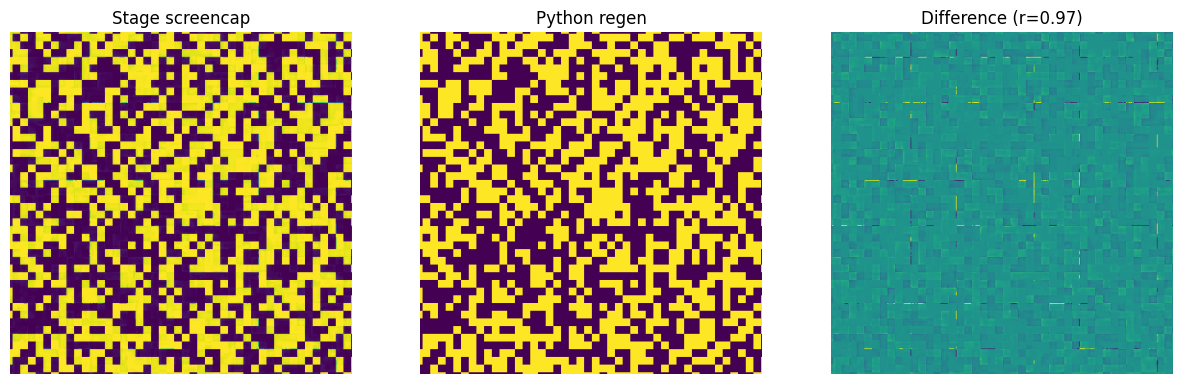

In [ ]:
import importlib
importlib.reload(regen)
true_canvas_size = (400, 600)
d_wn = regen.make_spatial_noise(sb0.df_epochs, canvas_size=true_canvas_size)
r_frames = d_wn['frames'][0]
plot_frame_comparison(v_frames, r_frames)

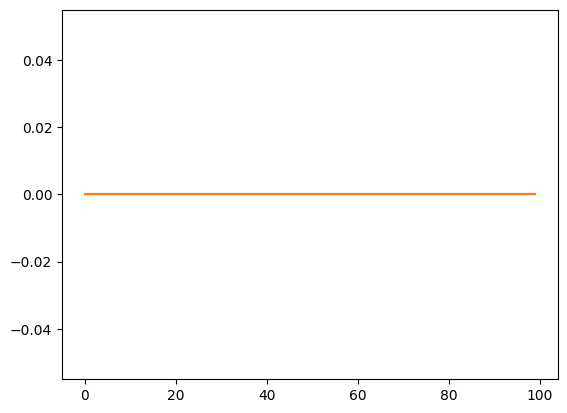

In [90]:
plt.plot(d_wn['steps'][0,:100,0])
plt.plot(d_wn['steps'][0,:100,1])

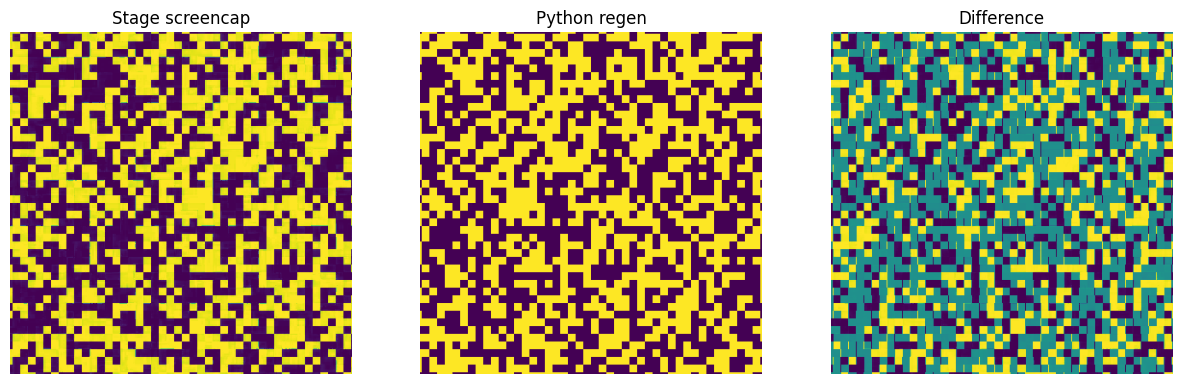

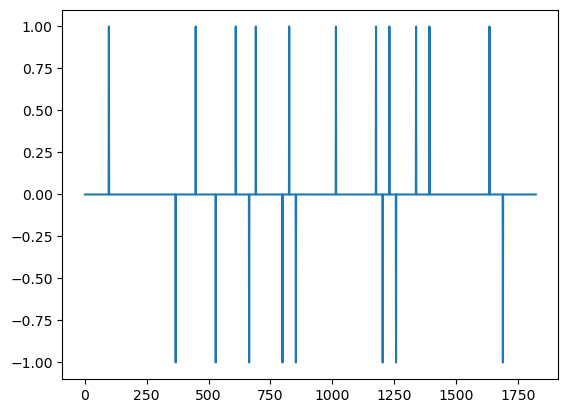

In [11]:
# plt.plot(s_frames[0,0,:600,0])
# plt.plot(r_frames[0,0,:600,0])
plt.plot(s_frames[0,0,:,0] - r_frames[0,0,:,0])

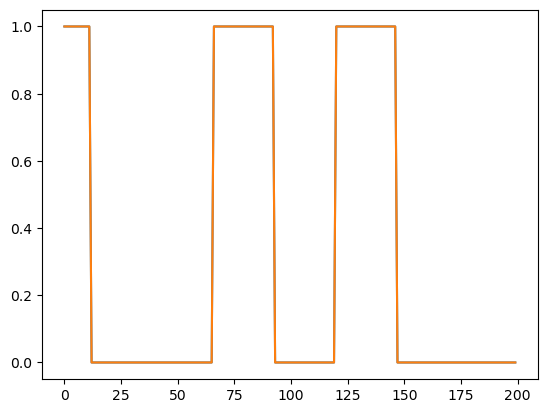

In [12]:
plt.plot(s_frames[0,:200, 0,0])
plt.plot(r_frames[0,:200, 0,0])


In [13]:
r_frames.shape, s_frames.shape

((50, 1140, 1824, 3), (85, 1140, 1824, 3))

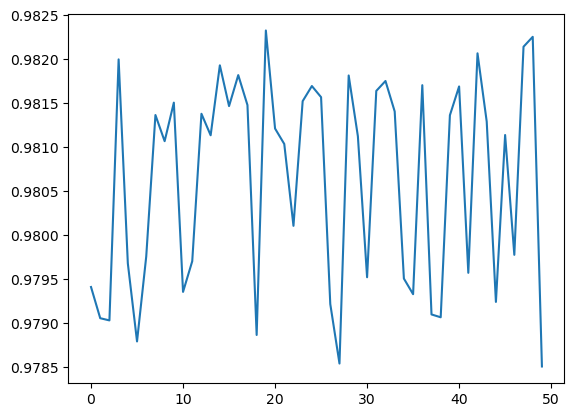

In [14]:
import cv2
ls_corrs = []
for t in range(50):
    # ds = cv2.resize(r_frames[t], (s_frames.shape[2], s_frames.shape[1]), interpolation=cv2.INTER_NEAREST)
    r = np.corrcoef(s_frames[t].flatten(), r_frames[t].flatten())[0,1]
    ls_corrs.append(r)
plt.plot(ls_corrs)